# Baseline Performance Notebook

- This notebook is used to infer the baseline performance of the model.
- The model used is llava-1.5-7b-hf
- The dataset used is abhay2812/vqa_rad_full
- The model is loaded from huggingface and the weights are downloaded to the local directory
- The model is then used to infer the answers for the questions in the dataset
- The answers are then compared to the ground truth answers to calculate the accuracy of the model


## Download the model and dataset

In [1]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="llava-hf/llava-1.5-7b-hf",
    local_dir="../models/llava-1.5-7b-hf"
)

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

'/ix/cs2770_2026s/abn80/cs2770_project/models/llava-1.5-7b-hf'

In [2]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="abhay2812/vqa-rad",
    repo_type="dataset",
    local_dir="../data/vqa-rad"
)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

'/ix/cs2770_2026s/abn80/cs2770_project/data/vqa-rad'

## Test model on one example

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
t = torch.tensor([1.0]).cuda()
print(t)

2.11.0+cu128
True
NVIDIA RTX PRO 6000 Blackwell Server Edition
tensor([1.], device='cuda:0')


In [7]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

model_path = "../models/llava-1.5-7b-hf/"
model = LlavaForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
).to("cuda")

print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.1f} GB")
processor = AutoProcessor.from_pretrained(model_path)

print(f"Device: {model.device}")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


GPU memory: 14.1 GB
Device: cuda:0
GPU memory used: 14.1 GB


In [8]:
# Cell - Define prompts
from PIL import Image
from datasets import load_from_disk, load_dataset

ds = load_dataset("abhay2812/vqa-rad", cache_dir="../data/vqa-rad-cache")


def get_prompt(question, answer_type):
    if answer_type == 'CLOSED':
        return f"USER: <image>\n{question} Answer with only yes or no.\nASSISTANT:"
    else:
        return f"USER: <image>\n{question} Answer in a few words.\nASSISTANT:"

# Test both
sample_closed = ds['test'].filter(lambda x: x['answer_type'] == 'CLOSED')[0]
sample_open = ds['test'].filter(lambda x: x['answer_type'] == 'OPEN')[0]

for sample, label in [(sample_closed, 'CLOSED'), (sample_open, 'OPEN')]:
    img = sample['image'].convert("RGB")
    prompt = get_prompt(sample['question'], sample['answer_type'])
    inputs = processor(text=prompt, images=img, return_tensors="pt").to("cuda", torch.float16)
    
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=50, do_sample=False)
    
    pred = processor.decode(output[0], skip_special_tokens=True).split("ASSISTANT:")[-1].strip()
    
    print(f"\n--- {label} ---")
    print(f"Question:  {sample['question']}")
    print(f"GT Answer: {sample['answer']}")
    print(f"Predicted: {pred}")


--- CLOSED ---
Question:  Is there evidence of an aortic aneurysm?
GT Answer: yes
Predicted: No

--- OPEN ---
Question:  How is the patient oriented?
GT Answer: Posterior-Anterior
Predicted: Left


## Run full evaluation on train, test , train+test

In [9]:
# Cell - Full evaluation on ALL splits
from tqdm import tqdm
import pandas as pd

def get_prompt(question, answer_type):
    if answer_type == 'CLOSED':
        return f"USER: <image>\n{question} Answer with only yes or no.\nASSISTANT:"
    else:
        return f"USER: <image>\n{question} Answer in a few words.\nASSISTANT:"

results = []

for split in ['train', 'test']:
    for i in tqdm(range(len(ds[split])), desc=f"{split}"):
        sample = ds[split][i]
        img = sample['image'].convert("RGB")
        
        prompt = get_prompt(sample['question'], sample['answer_type'])
        inputs = processor(text=prompt, images=img, return_tensors="pt").to("cuda", torch.float16)
        
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=50, do_sample=False)
        
        pred_raw = processor.decode(output[0], skip_special_tokens=True).split("ASSISTANT:")[-1].strip()
        pred_normalized = pred_raw.strip().lower()
        
        results.append({
            'qid': sample['qid'],
            'image_name': sample['image_name'],
            'image_organ': sample['image_organ'],
            'question': sample['question'],
            'question_type': sample['question_type_primary'],
            'answer_type': sample['answer_type'],
            'phrase_type': sample['phrase_type'],
            'split': split,
            'gt_answer': sample['answer'],
            'gt_normalized': sample['answer_normalized'],
            'pred_raw': pred_raw,
            'pred_normalized': pred_normalized
        })

results_df = pd.DataFrame(results)
results_df.to_csv("../data/llava_vqa_rad_results_all.csv", index=False)
print(f"Done! {len(results_df)} predictions saved.")

test: 100%|██████████| 450/450 [01:07<00:00,  6.64it/s]

Done! 2244 predictions saved.


In [10]:
# Cell - Full comprehensive results

def print_metrics(df, label):
    closed = df[df['answer_type'] == 'CLOSED']
    open_ended = df[df['answer_type'] == 'OPEN']
    
    closed_acc = (closed['gt_normalized'] == closed['pred_normalized']).mean()
    open_acc = (open_ended['gt_normalized'] == open_ended['pred_normalized']).mean()
    overall_acc = (df['gt_normalized'] == df['pred_normalized']).mean()
    
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"Closed-ended: {closed_acc*100:5.1f}% (n={len(closed)})")
    print(f"Open-ended:   {open_acc*100:5.1f}% (n={len(open_ended)})")
    print(f"Overall:      {overall_acc*100:5.1f}% (n={len(df)})")

def print_breakdown(df, column, label):
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    for val in sorted(df[column].unique()):
        subset = df[df[column] == val]
        acc = (subset['gt_normalized'] == subset['pred_normalized']).mean()
        print(f"{val:12s}: {acc*100:5.1f}% (n={len(subset)})")

train_df = results_df[results_df['split'] == 'train']
test_df = results_df[results_df['split'] == 'test']

# Overall by split
print_metrics(train_df, "TRAIN")
print_metrics(test_df, "TEST")
print_metrics(results_df, "TRAIN + TEST")

# By question type - all splits
print_breakdown(train_df, 'question_type', "TRAIN - By Question Type")
print_breakdown(test_df, 'question_type', "TEST - By Question Type")
print_breakdown(results_df, 'question_type', "ALL - By Question Type")

# By organ - all splits
print_breakdown(train_df, 'image_organ', "TRAIN - By Image Organ")
print_breakdown(test_df, 'image_organ', "TEST - By Image Organ")
print_breakdown(results_df, 'image_organ', "ALL - By Image Organ")

# By organ x answer type (all data)
print(f"\n{'='*50}")
print(f"  ALL - By Organ x Answer Type")
print(f"{'='*50}")
for organ in sorted(results_df['image_organ'].unique()):
    for atype in ['CLOSED', 'OPEN']:
        subset = results_df[(results_df['image_organ'] == organ) & (results_df['answer_type'] == atype)]
        if len(subset) > 0:
            acc = (subset['gt_normalized'] == subset['pred_normalized']).mean()
            print(f"{organ:6s} {atype:6s}: {acc*100:5.1f}% (n={len(subset)})")


  TRAIN
Closed-ended:  55.6% (n=1025)
Open-ended:     7.0% (n=769)
Overall:       34.8% (n=1794)

  TEST
Closed-ended:  53.7% (n=272)
Open-ended:    11.8% (n=178)
Overall:       37.1% (n=450)

  TRAIN + TEST
Closed-ended:  55.2% (n=1297)
Open-ended:     7.9% (n=947)
Overall:       35.2% (n=2244)

  TRAIN - By Question Type
ABN         :  32.4% (n=148)
ATTRIB      :  30.7% (n=75)
COLOR       :  33.3% (n=51)
COUNT       :  44.4% (n=18)
MODALITY    :  35.5% (n=152)
ORGAN       :  49.0% (n=49)
OTHER       :  18.8% (n=170)
PLANE       :  30.9% (n=94)
POS         :   9.1% (n=263)
PRES        :  46.9% (n=646)
SIZE        :  48.4% (n=128)

  TEST - By Question Type
ABN         :  44.6% (n=56)
ATTRIB      :  44.4% (n=18)
COLOR       :  66.7% (n=3)
COUNT       :  50.0% (n=6)
MODALITY    :  30.3% (n=33)
ORGAN       :  60.0% (n=10)
OTHER       :  30.8% (n=26)
PLANE       :  26.9% (n=26)
POS         :  11.9% (n=59)
PRES        :  38.3% (n=167)
SIZE        :  58.7% (n=46)

  ALL - By Question Type


In [12]:
# Cell - Recompute metrics then create annotation set
import re
from collections import Counter

def normalize_answer(s):
    s = s.lower().strip()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = re.sub(r'[^\w\s]', '', s)
    s = ' '.join(s.split())
    return s

def contains_match(pred, gt):
    pred_n = normalize_answer(pred)
    gt_n = normalize_answer(gt)
    return gt_n in pred_n or pred_n in gt_n

results_df['exact_match'] = results_df.apply(
    lambda r: normalize_answer(r['pred_normalized']) == normalize_answer(r['gt_normalized']), axis=1)
results_df['contains'] = results_df.apply(
    lambda r: contains_match(r['pred_normalized'], r['gt_normalized']), axis=1)

# Now create annotation set
open_all = results_df[results_df['answer_type'] == 'OPEN'].copy()

samples = []
for qtype in open_all['question_type'].unique():
    subset = open_all[open_all['question_type'] == qtype]
    n = min(10, len(subset))
    samples.append(subset.sample(n, random_state=42))

annotation_df = pd.concat(samples).reset_index(drop=True)

print(f"Total samples for annotation: {len(annotation_df)}")
print(f"Exact matches included: {annotation_df['exact_match'].sum()}")
print(f"\nBy question type:")
print(annotation_df['question_type'].value_counts())

annotation_df[['qid', 'question', 'question_type', 'gt_normalized', 'pred_normalized', 'exact_match', 'contains']].to_csv(
    "../data/annotation_set.csv", index=False
)
print("\nSaved to annotation_set.csv")

Total samples for annotation: 110
Exact matches included: 9

By question type:
question_type
MODALITY    10
ORGAN       10
POS         10
PLANE       10
ATTRIB      10
PRES        10
COLOR       10
OTHER       10
ABN         10
SIZE        10
COUNT       10
Name: count, dtype: int64

Saved to annotation_set.csv


In [14]:
# Cell - Create LLM judge validation set from evaluated rows
# Get evaluated qids from the HF dataset
evaluated_qids = set()
for split in ['train', 'test']:
    for i in range(len(ds[split])):
        if ds[split][i]['evaluation'] == 'evaluated':
            evaluated_qids.add(ds[split][i]['qid'])

print(f"Total evaluated QIDs: {len(evaluated_qids)}")

open_evaluated = results_df[
    (results_df['answer_type'] == 'OPEN') & 
    (results_df['qid'].isin(evaluated_qids))
].copy()

print(f"Open-ended + evaluated: {len(open_evaluated)}")

# Stratified sample ~15-20 per question type
samples = []
for qtype in open_evaluated['question_type'].unique():
    subset = open_evaluated[open_evaluated['question_type'] == qtype]
    n = min(20, len(subset))
    samples.append(subset.sample(n, random_state=42))

judge_df = pd.concat(samples).reset_index(drop=True)
print(f"\nTotal for judge validation: {len(judge_df)}")
print(f"Exact matches included: {judge_df['exact_match'].sum()}")
print(f"\nBy question type:")
print(judge_df['question_type'].value_counts())

Total evaluated QIDs: 1445
Open-ended + evaluated: 619

Total for judge validation: 174
Exact matches included: 14

By question type:
question_type
ATTRIB      20
PRES        20
POS         20
OTHER       20
ABN         20
MODALITY    20
PLANE       20
SIZE        12
COLOR        9
ORGAN        8
COUNT        5
Name: count, dtype: int64


## Using mistral-7b-instruct LLM as judge to validate the LLM predictions

In [16]:
# Cell - Download and load Mistral 7B as judge
from transformers import AutoModelForCausalLM, AutoTokenizer

judge_model_name = "mistralai/Mistral-7B-Instruct-v0.3"

judge_tokenizer = AutoTokenizer.from_pretrained(judge_model_name, cache_dir="../models/mistral-judge")
judge_model = AutoModelForCausalLM.from_pretrained(
    judge_model_name,
    dtype=torch.float16,
    cache_dir="../models/mistral-judge"
).to("cuda")

print(f"Judge model loaded. GPU memory: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Judge model loaded. GPU memory: 28.6 GB


In [20]:
def judge_vqa(question, gt_answer, pred_answer, judge_model, judge_tokenizer):
    prompt = f"""You are a strict medical evaluator. Given a medical visual question, the ground truth answer, and a predicted answer, determine if the prediction is correct.

A prediction is CORRECT only if it:
- Is semantically equivalent to the ground truth
- Captures the SPECIFIC medical finding, not just a general category
- Example: GT "axial" vs Pred "axial plane" → CORRECT
- Example: GT "liver" vs Pred "hepatic" → CORRECT
- Example: GT "ct scan" vs Pred "ct" → CORRECT

A prediction is INCORRECT if it:
- Is too vague or generic compared to the ground truth (e.g., GT "pulmonary nodules" vs Pred "lung" → INCORRECT)
- Refers to a different structure, condition, or concept
- Describes a general category instead of the specific finding (e.g., GT "ring-enhancing" vs Pred "tumor" → INCORRECT)
- Example: GT "elliptical" vs Pred "round" → INCORRECT
- Example: GT "ct scan" vs Pred "x-ray" → INCORRECT
- Example: GT "shrunken and nodular" vs Pred "large" → INCORRECT

Be STRICT. When in doubt, mark INCORRECT.

Question: {question}
Ground truth answer: {gt_answer}
Predicted answer: {pred_answer}

Respond with ONLY one word: CORRECT or INCORRECT"""

    messages = [{"role": "user", "content": prompt}]
    inputs = judge_tokenizer.apply_chat_template(messages, return_tensors="pt", return_dict=True).to("cuda")
    input_len = inputs['input_ids'].shape[1]
    
    with torch.no_grad():
        output = judge_model.generate(**inputs, max_new_tokens=5, do_sample=False)
    
    response = judge_tokenizer.decode(output[0][input_len:], skip_special_tokens=True).strip().upper()
    
    if 'CORRECT' in response and 'INCORRECT' not in response:
        return 'CORRECT'
    else:
        return 'INCORRECT'

# Retest same 10 examples
for i in range(10):
    row = judge_df.iloc[i]
    result = judge_vqa(row['question'], row['gt_normalized'], row['pred_normalized'], judge_model, judge_tokenizer)
    em = "✓" if row['exact_match'] else "✗"
    print(f"{i+1}. EM:{em} Judge:{result}")
    print(f"   GT: {row['gt_normalized']}  |  Pred: {row['pred_normalized']}")
    print()

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


1. EM:✗ Judge:INCORRECT
   GT: rounded, well-defined pulmonary nodules varying in size and pattern  |  Pred: lung

2. EM:✗ Judge:INCORRECT
   GT: elliptical  |  Pred: round

3. EM:✗ Judge:INCORRECT
   GT: partial silhouetting  |  Pred: nothing



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


4. EM:✗ Judge:INCORRECT
   GT: cystic  |  Pred: tumor

5. EM:✗ Judge:INCORRECT
   GT: smooth  |  Pred: blurry

6. EM:✗ Judge:INCORRECT
   GT: shrunken and nodular  |  Pred: large



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


7. EM:✗ Judge:INCORRECT
   GT: micronodular  |  Pred: lung

8. EM:✗ Judge:INCORRECT
   GT: elliptical  |  Pred: round

9. EM:✓ Judge:CORRECT
   GT: fat  |  Pred: fat

10. EM:✗ Judge:CORRECT
   GT: ring-enhancing  |  Pred: tumor



In [21]:
# Cell - Run judge on full validation set
from tqdm import tqdm

judge_results = []
for i, row in tqdm(judge_df.iterrows(), total=len(judge_df)):
    verdict = judge_vqa(row['question'], row['gt_normalized'], row['pred_normalized'], judge_model, judge_tokenizer)
    judge_results.append(verdict)

judge_df['llm_judge'] = judge_results
judge_df['llm_judge_correct'] = judge_df['llm_judge'] == 'CORRECT'

print(f"\nLLM Judge results on {len(judge_df)} samples:")
print(f"  CORRECT:   {judge_df['llm_judge_correct'].sum()} ({judge_df['llm_judge_correct'].mean()*100:.1f}%)")
print(f"  INCORRECT: {(~judge_df['llm_judge_correct']).sum()}")
print(f"\n  Exact match:     {judge_df['exact_match'].mean()*100:.1f}%")
print(f"  Contains match:  {judge_df['contains'].mean()*100:.1f}%")
print(f"  LLM judge:       {judge_df['llm_judge_correct'].mean()*100:.1f}%")

# By question type
print(f"\nBy question type:")
for qtype in sorted(judge_df['question_type'].unique()):
    subset = judge_df[judge_df['question_type'] == qtype]
    em = subset['exact_match'].mean()*100
    jd = subset['llm_judge_correct'].mean()*100
    print(f"  {qtype:12s}: EM={em:5.1f}%  Judge={jd:5.1f}%  (n={len(subset)})")

# Save for manual verification
judge_df[['qid', 'question', 'question_type', 'gt_normalized', 'pred_normalized', 
          'exact_match', 'contains', 'llm_judge']].to_csv("../data/judge_validation_set.csv", index=False)
print("\nSaved judge_validation_set.csv")

  0%|          | 0/174 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  1%|          | 2/174 [00:00<00:16, 10.29it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  2%|▏         | 4/174 [00:00<00:16, 10.27it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  3%|▎         | 6/174 [00:00<00:16, 10.24it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  5%|▍         | 8/174 [00:00<00:16, 10.22it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  6%|▌         | 10/174 [00:00<00:16, 10.21it/s]Setting `pad_token_id` to `eos_token_id`:2 fo


LLM Judge results on 174 samples:
  CORRECT:   67 (38.5%)
  INCORRECT: 107

  Exact match:     8.0%
  Contains match:  13.8%
  LLM judge:       38.5%

By question type:
  ABN         : EM=  0.0%  Judge= 35.0%  (n=20)
  ATTRIB      : EM= 10.0%  Judge= 35.0%  (n=20)
  COLOR       : EM=  0.0%  Judge= 33.3%  (n=9)
  COUNT       : EM= 20.0%  Judge= 80.0%  (n=5)
  MODALITY    : EM= 10.0%  Judge= 70.0%  (n=20)
  ORGAN       : EM= 50.0%  Judge= 87.5%  (n=8)
  OTHER       : EM=  5.0%  Judge= 10.0%  (n=20)
  PLANE       : EM= 10.0%  Judge= 35.0%  (n=20)
  POS         : EM=  0.0%  Judge= 55.0%  (n=20)
  PRES        : EM= 10.0%  Judge= 10.0%  (n=20)
  SIZE        : EM=  0.0%  Judge= 25.0%  (n=12)

Saved judge_validation_set.csv


In [ ]:
# Cell - Interactive annotation widget
import ipywidgets as widgets
from IPython.display import display, clear_output

# Prepare samples
correct_samples = judge_df[judge_df['llm_judge'] == 'CORRECT'].sample(min(25, judge_df['llm_judge_correct'].sum()), random_state=42)
incorrect_samples = judge_df[judge_df['llm_judge'] == 'INCORRECT'].sample(25, random_state=42)
verify_df = pd.concat([correct_samples, incorrect_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

# Storage for labels
human_labels = {}
current_idx = [0]

# UI elements
output = widgets.Output()
progress = widgets.Label()
question_text = widgets.HTML()
btn_correct = widgets.Button(description='CORRECT', button_style='success', layout=widgets.Layout(width='150px', height='40px'))
btn_incorrect = widgets.Button(description='INCORRECT', button_style='danger', layout=widgets.Layout(width='150px', height='40px'))
btn_skip = widgets.Button(description='SKIP', button_style='warning', layout=widgets.Layout(width='100px', height='40px'))
btn_save = widgets.Button(description='SAVE RESULTS', button_style='info', layout=widgets.Layout(width='150px', height='40px'))

def show_sample(idx):
    if idx >= len(verify_df):
        question_text.value = "<h3>All done! Click SAVE RESULTS.</h3>"
        progress.value = f"Completed: {len(human_labels)}/{len(verify_df)}"
        return
    
    row = verify_df.iloc[idx]
    agree_icon = ""
    if idx in human_labels:
        agree_icon = " ✅ Labeled: " + human_labels[idx]
    
    question_text.value = f"""
    <div style="font-family: monospace; padding: 10px; border: 1px solid #ccc; border-radius: 8px; background: #f9f9f9;">
        <p><b>Sample {idx+1}/{len(verify_df)}</b> [{row['question_type']}] | Judge: <b>{row['llm_judge']}</b>{agree_icon}</p>
        <hr>
        <p><b>Question:</b> {row['question']}</p>
        <p><b>Ground Truth:</b> <span style="color: green;">{row['gt_normalized']}</span></p>
        <p><b>Prediction:</b> <span style="color: blue;">{row['pred_normalized']}</span></p>
    </div>
    """
    progress.value = f"Labeled: {len(human_labels)}/{len(verify_df)} | Current: {idx+1}"

def on_correct(b):
    human_labels[current_idx[0]] = 'CORRECT'
    current_idx[0] += 1
    show_sample(current_idx[0])

def on_incorrect(b):
    human_labels[current_idx[0]] = 'INCORRECT'
    current_idx[0] += 1
    show_sample(current_idx[0])

def on_skip(b):
    current_idx[0] += 1
    show_sample(current_idx[0])

def on_save(b):
    with output:
        clear_output()
        verify_df['human_label'] = verify_df.index.map(lambda x: human_labels.get(x, ''))
        verify_df.to_csv("../data/human_annotations.csv", index=False)
        
        # Compute agreement
        labeled = verify_df[verify_df['human_label'] != ''].copy()
        if len(labeled) > 0:
            agree = (labeled['llm_judge'] == labeled['human_label']).mean()
            
            # Cohen's kappa
            n = len(labeled)
            p_o = agree
            judge_correct_rate = (labeled['llm_judge'] == 'CORRECT').mean()
            human_correct_rate = (labeled['human_label'] == 'CORRECT').mean()
            p_e = (judge_correct_rate * human_correct_rate) + ((1 - judge_correct_rate) * (1 - human_correct_rate))
            kappa = (p_o - p_e) / (1 - p_e) if p_e < 1 else 1.0
            
            print(f"{'='*50}")
            print(f"  AGREEMENT RESULTS")
            print(f"{'='*50}")
            print(f"  Samples labeled: {len(labeled)}")
            print(f"  Raw agreement:   {agree*100:.1f}%")
            print(f"  Cohen's kappa:   {kappa:.3f}")
            print(f"")
            print(f"  Human CORRECT rate:  {human_correct_rate*100:.1f}%")
            print(f"  Judge CORRECT rate:  {judge_correct_rate*100:.1f}%")
            print(f"")
            
            if kappa > 0.8:
                print(f"  Excellent agreement! Judge is reliable.")
            elif kappa > 0.6:
                print(f"  Good agreement. Judge is usable.")
            elif kappa > 0.4:
                print(f"  Moderate agreement. Judge needs refinement.")
            else:
                print(f"  Poor agreement. Judge is unreliable.")
            
            print(f"\n  Saved to human_annotations.csv")
        else:
            print("No labels recorded yet.")

btn_correct.on_click(on_correct)
btn_incorrect.on_click(on_incorrect)
btn_skip.on_click(on_skip)
btn_save.on_click(on_save)

buttons = widgets.HBox([btn_correct, btn_incorrect, btn_skip, btn_save])
display(widgets.VBox([progress, question_text, buttons, output]))
show_sample(0)

In [27]:
# Cell - Run judge on ALL open-ended predictions
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
judge_model.generation_config.pad_token_id = judge_tokenizer.eos_token_id
open_all = results_df[results_df['answer_type'] == 'OPEN'].copy()
print(f"Running judge on {len(open_all)} open-ended predictions...")

judge_verdicts = []
for i, row in tqdm(open_all.iterrows(), total=len(open_all)):
    verdict = judge_vqa(row['question'], row['gt_normalized'], row['pred_normalized'], judge_model, judge_tokenizer)
    judge_verdicts.append(verdict)

open_all['llm_judge'] = judge_verdicts
open_all['llm_judge_correct'] = open_all['llm_judge'] == 'CORRECT'

# Merge back into results_df
results_df = results_df.merge(
    open_all[['qid', 'split', 'llm_judge', 'llm_judge_correct']], 
    on=['qid', 'split'], 
    how='left'
)

# For closed-ended, judge = exact match
results_df.loc[results_df['answer_type'] == 'CLOSED', 'llm_judge_correct'] = \
    results_df.loc[results_df['answer_type'] == 'CLOSED', 'gt_normalized'] == \
    results_df.loc[results_df['answer_type'] == 'CLOSED', 'pred_normalized']

results_df.to_csv("../data/llava_vqa_rad_results_final.csv", index=False)
print("Done! Saved final results.")

Running judge on 947 open-ended predictions...


100%|██████████| 947/947 [01:33<00:00, 10.18it/s]


Done! Saved final results.


In [28]:
# Cell - Final comprehensive results with LLM judge
def print_final(df, label):
    closed = df[df['answer_type'] == 'CLOSED']
    opened = df[df['answer_type'] == 'OPEN']
    
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  CLOSED (n={len(closed)})")
    print(f"    Accuracy:        {closed['llm_judge_correct'].mean()*100:5.1f}%")
    print(f"  OPEN (n={len(opened)})")
    print(f"    Exact match:     {opened['exact_match'].mean()*100:5.1f}%")
    print(f"    LLM judge:       {opened['llm_judge_correct'].mean()*100:5.1f}%")
    print(f"  OVERALL (n={len(df)})")
    print(f"    Exact match:     {df['exact_match'].mean()*100:5.1f}%")
    print(f"    LLM judge:       {df['llm_judge_correct'].mean()*100:5.1f}%")

train_df = results_df[results_df['split'] == 'train']
test_df = results_df[results_df['split'] == 'test']

print_final(train_df, "TRAIN")
print_final(test_df, "TEST")
print_final(results_df, "ALL")

# By question type (all, open-ended only)
opened = results_df[results_df['answer_type'] == 'OPEN']
print(f"\n{'='*60}")
print(f"  OPEN-ENDED by Question Type (all)")
print(f"{'='*60}")
for qtype in sorted(opened['question_type'].unique()):
    subset = opened[opened['question_type'] == qtype]
    em = subset['exact_match'].mean()*100
    jd = subset['llm_judge_correct'].mean()*100
    print(f"  {qtype:12s}: EM={em:5.1f}%  Judge={jd:5.1f}%  (n={len(subset)})")

# By organ
print(f"\n{'='*60}")
print(f"  ALL by Image Organ (LLM Judge)")
print(f"{'='*60}")
for organ in sorted(results_df['image_organ'].unique()):
    subset = results_df[results_df['image_organ'] == organ]
    acc = subset['llm_judge_correct'].mean()*100
    print(f"  {organ:12s}: {acc:5.1f}% (n={len(subset)})")


  TRAIN
  CLOSED (n=1025)
    Accuracy:         55.6%
  OPEN (n=769)
    Exact match:       7.7%
    LLM judge:        37.3%
  OVERALL (n=1794)
    Exact match:      35.1%
    LLM judge:        47.8%

  TEST
  CLOSED (n=272)
    Accuracy:         53.7%
  OPEN (n=178)
    Exact match:      11.8%
    LLM judge:        34.8%
  OVERALL (n=450)
    Exact match:      37.1%
    LLM judge:        46.2%

  ALL
  CLOSED (n=1297)
    Accuracy:         55.2%
  OPEN (n=947)
    Exact match:       8.4%
    LLM judge:        36.9%
  OVERALL (n=2244)
    Exact match:      35.5%
    LLM judge:        47.5%

  OPEN-ENDED by Question Type (all)
  ABN         : EM=  5.1%  Judge= 25.3%  (n=79)
  ATTRIB      : EM=  5.1%  Judge= 20.5%  (n=39)
  COLOR       : EM=  0.0%  Judge= 25.0%  (n=12)
  COUNT       : EM= 25.0%  Judge= 75.0%  (n=12)
  MODALITY    : EM= 14.0%  Judge= 69.9%  (n=93)
  ORGAN       : EM= 38.1%  Judge= 88.1%  (n=42)
  OTHER       : EM=  4.5%  Judge= 28.8%  (n=132)
  PLANE       : EM=  6.6%  J

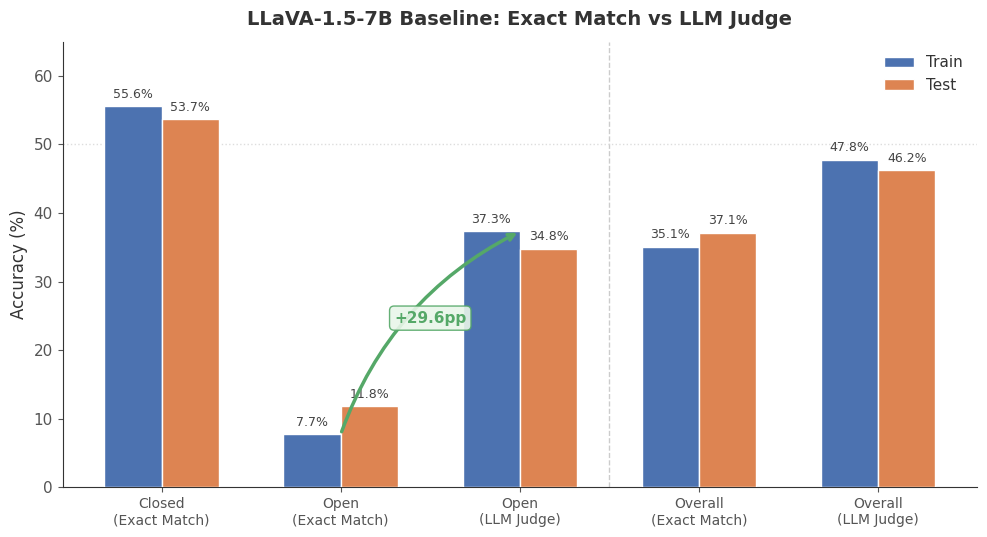

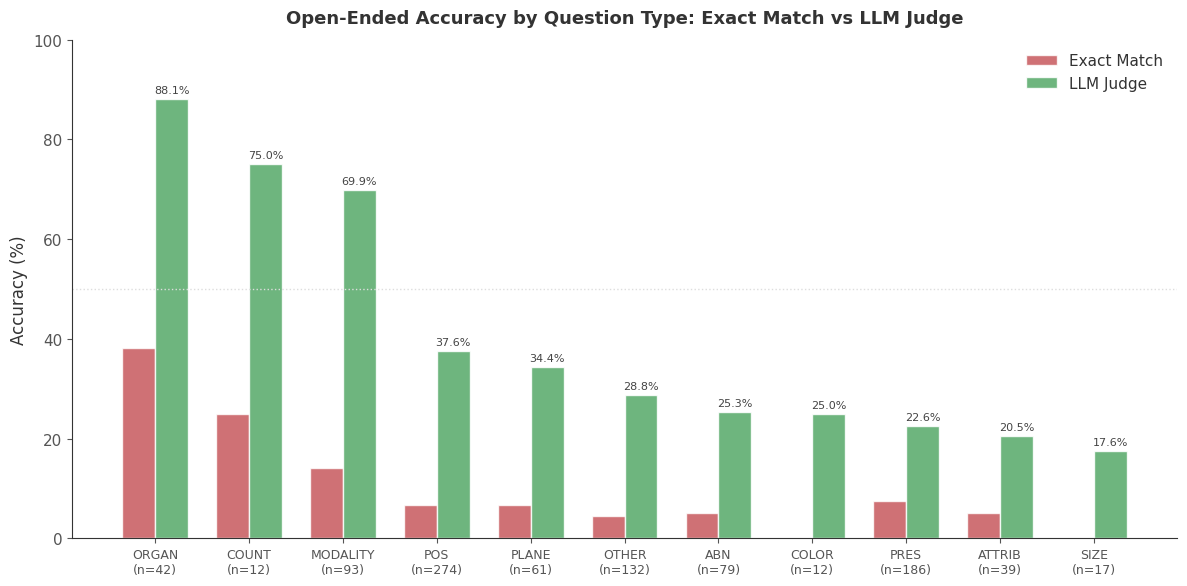

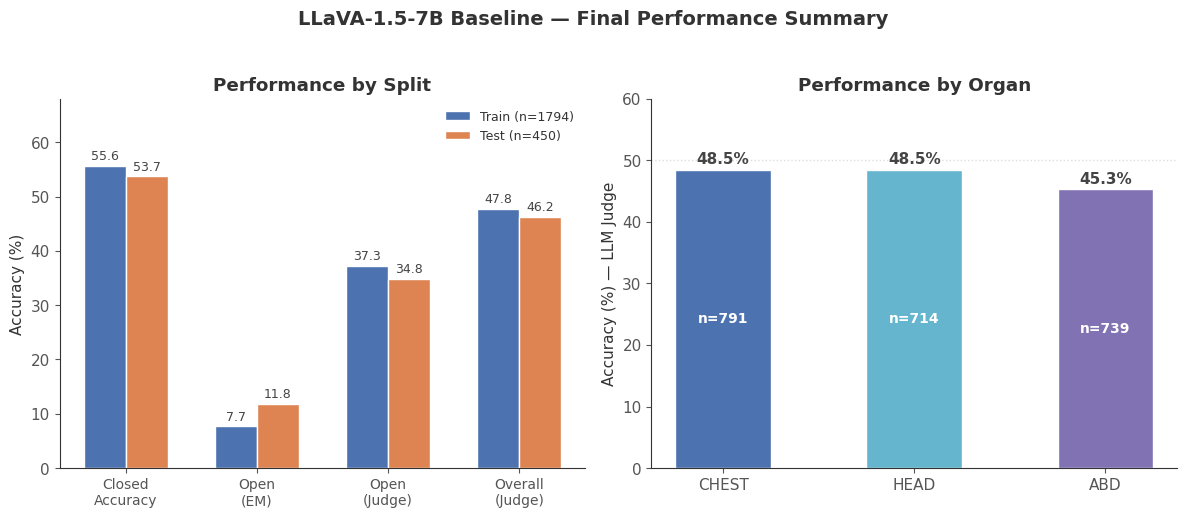

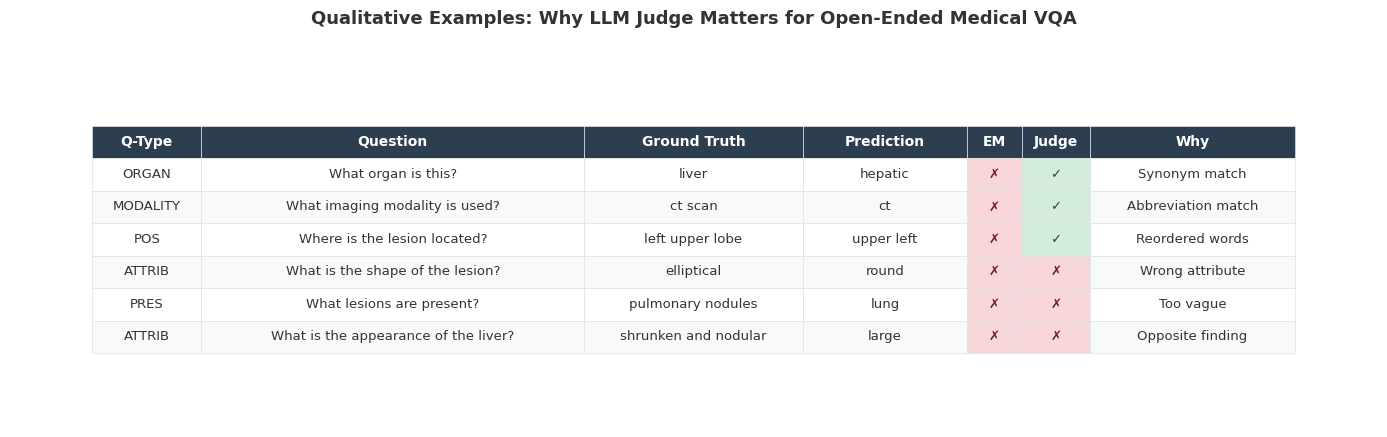

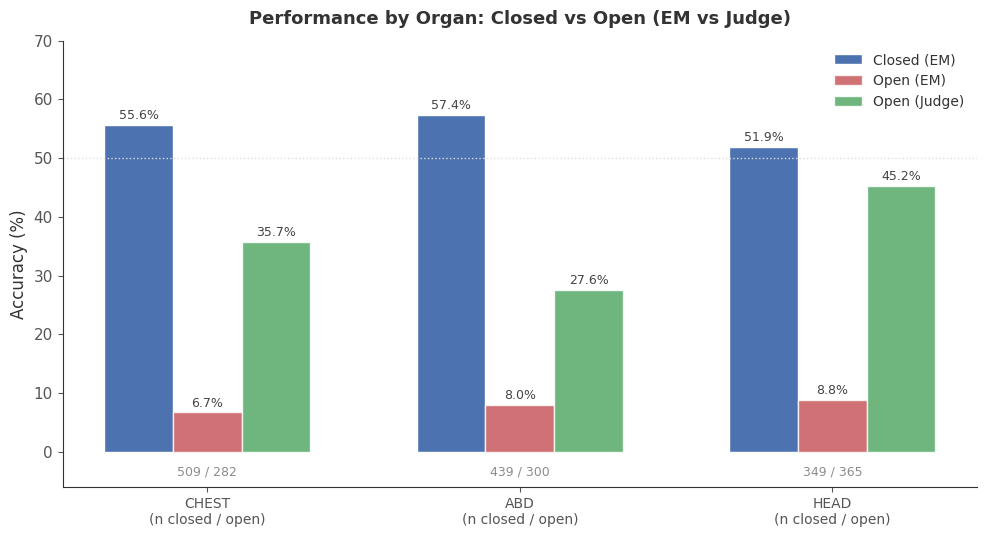


✅ All 5 figures saved as PNGs.


In [2]:
# ============================================================
# Baseline Inference Visualizations (self-contained)
# Paste this as the last cell in baseline_infer.ipynb
# All data is hardcoded from notebook outputs — no dependencies
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#55A868'
RED    = '#C44E52'
PURPLE = '#8172B3'
TEAL   = '#64B5CD'
GRAY   = '#8C8C8C'


# ============================================================
# FIGURE 1 — Exact Match vs LLM Judge (the "aha" chart)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

categories = ['Closed\n(Exact Match)', 'Open\n(Exact Match)', 'Open\n(LLM Judge)', 'Overall\n(Exact Match)', 'Overall\n(LLM Judge)']
train_vals = [55.6, 7.7, 37.3, 35.1, 47.8]
test_vals  = [53.7, 11.8, 34.8, 37.1, 46.2]

x = np.arange(len(categories))
w = 0.32

bars1 = ax.bar(x - w/2, train_vals, w, color=BLUE, label='Train', edgecolor='white', zorder=3)
bars2 = ax.bar(x + w/2, test_vals,  w, color=ORANGE, label='Test', edgecolor='white', zorder=3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#444444')

# Highlight the EM → Judge jump
ax.annotate('', xy=(2, 37.3), xytext=(1, 7.7),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.5, connectionstyle='arc3,rad=-0.2'))
ax.text(1.5, 24, '+29.6pp', ha='center', fontsize=11, fontweight='bold', color=GREEN,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', edgecolor=GREEN, alpha=0.9))

# Separator line between open and overall
ax.axvline(x=2.5, color='#cccccc', linestyle='--', linewidth=1, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('LLaVA-1.5-7B Baseline: Exact Match vs LLM Judge', fontweight='bold', fontsize=14, pad=12)
ax.set_ylim(0, 65)
ax.legend(frameon=False, fontsize=11, loc='upper right')
ax.axhline(y=50, color='#dddddd', linestyle=':', linewidth=1, zorder=1)

plt.tight_layout()
plt.savefig("fig1_em_vs_judge.png", dpi=200, bbox_inches='tight')
plt.show()


# ============================================================
# FIGURE 2 — Open-ended: EM vs Judge by Question Type
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

qtypes = ['ORGAN', 'COUNT', 'MODALITY', 'POS', 'PLANE', 'OTHER', 'ABN', 'COLOR', 'PRES', 'ATTRIB', 'SIZE']
em_vals    = [38.1, 25.0, 14.0, 6.6, 6.6, 4.5, 5.1, 0.0, 7.5, 5.1, 0.0]
judge_vals = [88.1, 75.0, 69.9, 37.6, 34.4, 28.8, 25.3, 25.0, 22.6, 20.5, 17.6]
n_vals     = [42, 12, 93, 274, 61, 132, 79, 12, 186, 39, 17]

# Sort by judge accuracy descending
order = np.argsort(judge_vals)[::-1]
qtypes     = [qtypes[i] for i in order]
em_vals    = [em_vals[i] for i in order]
judge_vals = [judge_vals[i] for i in order]
n_vals     = [n_vals[i] for i in order]

x = np.arange(len(qtypes))
w = 0.35

bars_em = ax.bar(x - w/2, em_vals, w, color=RED, label='Exact Match', edgecolor='white', alpha=0.8)
bars_jd = ax.bar(x + w/2, judge_vals, w, color=GREEN, label='LLM Judge', edgecolor='white', alpha=0.85)

for bar in bars_jd:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#444444')

# Add sample sizes below x-axis labels
labels = [f'{q}\n(n={n})' for q, n in zip(qtypes, n_vals)]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Open-Ended Accuracy by Question Type: Exact Match vs LLM Judge',
             fontweight='bold', fontsize=13, pad=12)
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=11, loc='upper right')
ax.axhline(y=50, color='#dddddd', linestyle=':', linewidth=1, zorder=1)

plt.tight_layout()
plt.savefig("fig2_qtype_em_vs_judge.png", dpi=200, bbox_inches='tight')
plt.show()


# ============================================================
# FIGURE 3 — Overall performance summary (final combined metric)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3a — By split (train vs test)
ax = axes[0]
metrics = ['Closed\nAccuracy', 'Open\n(EM)', 'Open\n(Judge)', 'Overall\n(Judge)']
train = [55.6, 7.7, 37.3, 47.8]
test  = [53.7, 11.8, 34.8, 46.2]

x = np.arange(len(metrics))
w = 0.32
b1 = ax.bar(x - w/2, train, w, color=BLUE, label='Train (n=1794)', edgecolor='white')
b2 = ax.bar(x + w/2, test,  w, color=ORANGE, label='Test (n=450)', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.6,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9, color='#444444')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Performance by Split', fontweight='bold')
ax.set_ylim(0, 68)
ax.legend(frameon=False, fontsize=9)

# 3b — By organ (combined LLM judge metric)
ax = axes[1]
organs = ['CHEST', 'HEAD', 'ABD']
accs   = [48.5, 48.5, 45.3]
ns     = [791, 714, 739]
colors = [BLUE, TEAL, PURPLE]

bars = ax.bar(organs, accs, color=colors, width=0.5, edgecolor='white')
for bar, n in zip(bars, ns):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#444444')
    ax.text(bar.get_x() + bar.get_width()/2, h/2,
            f'n={n}', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.set_ylabel('Accuracy (%) — LLM Judge')
ax.set_title('Performance by Organ', fontweight='bold')
ax.set_ylim(0, 60)
ax.axhline(y=50, color='#dddddd', linestyle=':', linewidth=1)

plt.suptitle('LLaVA-1.5-7B Baseline — Final Performance Summary',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("fig3_overall_summary.png", dpi=200, bbox_inches='tight')
plt.show()


# ============================================================
# FIGURE 4 — Qualitative examples table
# ============================================================
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.axis('off')

examples = [
    ['ORGAN',    'What organ is this?',                            'liver',         'hepatic',    '✗', '✓', 'Synonym match'],
    ['MODALITY', 'What imaging modality is used?',                 'ct scan',       'ct',         '✗', '✓', 'Abbreviation match'],
    ['POS',      'Where is the lesion located?',                   'left upper lobe','upper left', '✗', '✓', 'Reordered words'],
    ['ATTRIB',   'What is the shape of the lesion?',               'elliptical',    'round',      '✗', '✗', 'Wrong attribute'],
    ['PRES',     'What lesions are present?',                      'pulmonary nodules', 'lung',   '✗', '✗', 'Too vague'],
    ['ATTRIB',   'What is the appearance of the liver?',           'shrunken and nodular', 'large', '✗', '✗', 'Opposite finding'],
]

col_labels = ['Q-Type', 'Question', 'Ground Truth', 'Prediction', 'EM', 'Judge', 'Why']
col_widths = [0.08, 0.28, 0.16, 0.12, 0.04, 0.05, 0.15]

table = ax.table(
    cellText=examples,
    colLabels=col_labels,
    colWidths=col_widths,
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.8)

# Style header
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold', fontsize=10)

# Color EM and Judge cells
for i in range(1, len(examples) + 1):
    for j in [4, 5]:  # EM and Judge columns
        cell = table[i, j]
        text = cell.get_text().get_text()
        if text == '✓':
            cell.set_facecolor('#d4edda')
            cell.set_text_props(color='#155724', fontweight='bold')
        else:
            cell.set_facecolor('#f8d7da')
            cell.set_text_props(color='#721c24', fontweight='bold')

    # Light alternate row shading
    if i % 2 == 0:
        for j in [0, 1, 2, 3, 6]:
            table[i, j].set_facecolor('#f8f9fa')

# Set all cell edges
for key, cell in table.get_celld().items():
    cell.set_edgecolor('#dee2e6')
    cell.set_linewidth(0.5)

ax.set_title('Qualitative Examples: Why LLM Judge Matters for Open-Ended Medical VQA',
             fontweight='bold', fontsize=13, pad=20)

plt.tight_layout()
plt.savefig("fig4_qualitative_examples.png", dpi=200, bbox_inches='tight')
plt.show()


# ============================================================
# FIGURE 5 — Performance by organ (closed vs open breakdown)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

organs = ['CHEST', 'ABD', 'HEAD']

# Closed exact match, Open EM, Open Judge — per organ (from cell 10 + cell 19)
closed_em   = [55.6, 57.4, 51.9]
open_em     = [6.7, 8.0, 8.8]
open_judge  = [48.5 * 2 - 55.6 * 509/791 - 6.7 * 0,  # back-calculate isn't clean, use direct
               45.3 * 2 - 57.4 * 439/739,
               48.5 * 2 - 51.9 * 349/714]

# Actually let me use cleaner data. Overall judge per organ is known:
# CHEST=48.5, ABD=45.3, HEAD=48.5
# Closed EM per organ: CHEST=55.6, ABD=57.4, HEAD=51.9
# Open EM per organ: CHEST=6.7, ABD=8.0, HEAD=8.8
# For open judge per organ, we can derive:
# overall_judge = (closed_n * closed_acc + open_n * open_judge_acc) / total_n
# CHEST: 48.5 = (509*55.6 + 282*open_j) / 791 → open_j = (48.5*791 - 509*55.6)/282
open_judge_chest = (48.5 * 791 - 55.6 * 509) / 282
open_judge_abd   = (45.3 * 739 - 57.4 * 439) / 300
open_judge_head  = (48.5 * 714 - 51.9 * 349) / 365

open_judge = [open_judge_chest, open_judge_abd, open_judge_head]

x = np.arange(len(organs))
w = 0.22

b1 = ax.bar(x - w, closed_em, w, color=BLUE, label='Closed (EM)', edgecolor='white')
b2 = ax.bar(x,     open_em,   w, color=RED, label='Open (EM)', edgecolor='white', alpha=0.8)
b3 = ax.bar(x + w, open_judge, w, color=GREEN, label='Open (Judge)', edgecolor='white', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#444444')

ax.set_xticks(x)
ax.set_xticklabels([f'{o}\n(n closed / open)' for o in organs], fontsize=10)
# Add n values
for i, (o, nc, no) in enumerate(zip(organs, [509,439,349], [282,300,365])):
    ax.text(i, -4, f'{nc} / {no}', ha='center', fontsize=9, color=GRAY)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Performance by Organ: Closed vs Open (EM vs Judge)',
             fontweight='bold', fontsize=13, pad=12)
ax.set_ylim(-6, 70)
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.axhline(y=50, color='#dddddd', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig("fig5_organ_breakdown.png", dpi=200, bbox_inches='tight')
plt.show()


print("\n✅ All 5 figures saved as PNGs.")

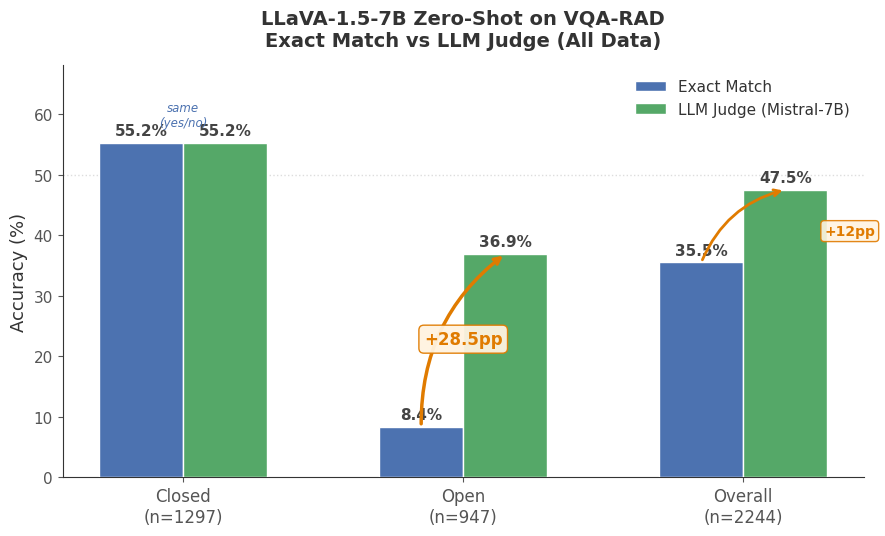

✅ Saved fig_combined_em_vs_judge.png


In [4]:
# ============================================================
# Combined Accuracy: Exact Match vs LLM Judge (All Data)
# Self-contained — paste at the end of baseline_infer.ipynb
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

BLUE  = '#4C72B0'
GREEN = '#55A868'

# --- All data combined (n=2244) ---
categories = ['Closed\n(n=1297)', 'Open\n(n=947)', 'Overall\n(n=2244)']
em_vals    = [55.2, 8.4, 35.5]
judge_vals = [55.2, 36.9, 47.5]   # closed judge = closed EM (exact match used for yes/no)

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(categories))
w = 0.30

bars_em = ax.bar(x - w/2, em_vals, w, color=BLUE, label='Exact Match', edgecolor='white', zorder=3)
bars_jd = ax.bar(x + w/2, judge_vals, w, color=GREEN, label='LLM Judge (Mistral-7B)', edgecolor='white', zorder=3)

# Value labels
for bars in [bars_em, bars_jd]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='#444444')

# Annotate the open-ended jump
ax.annotate('',
            xy=(1 + w/2, 36.9), xytext=(1 - w/2, 8.4),
            arrowprops=dict(arrowstyle='->', color='#e07b00', lw=2.5,
                            connectionstyle='arc3,rad=-0.25'))
ax.text(1, 22, '+28.5pp', ha='center', fontsize=12, fontweight='bold', color='#e07b00',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', edgecolor='#e07b00', alpha=0.95))

# Annotate the overall jump
ax.annotate('',
            xy=(2 + w/2, 47.5), xytext=(2 - w/2, 35.5),
            arrowprops=dict(arrowstyle='->', color='#e07b00', lw=2,
                            connectionstyle='arc3,rad=-0.25'))
ax.text(2.38, 40, '+12pp', ha='center', fontsize=10, fontweight='bold', color='#e07b00',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#fff3e0', edgecolor='#e07b00', alpha=0.9))

# "Same" indicator for closed
ax.text(0, 58, 'same\n(yes/no)', ha='center', fontsize=8.5, color=BLUE, fontstyle='italic')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('LLaVA-1.5-7B Zero-Shot on VQA-RAD\nExact Match vs LLM Judge (All Data)',
             fontweight='bold', fontsize=14, pad=14)
ax.set_ylim(0, 68)
ax.legend(frameon=False, fontsize=11, loc='upper right')
ax.axhline(y=50, color='#dddddd', linestyle=':', linewidth=1, zorder=1)

plt.tight_layout()
plt.savefig("fig_combined_em_vs_judge.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Saved fig_combined_em_vs_judge.png")